В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням алгоритмів бустингу: XGBoost та LightGBM, а також використаємо бібліотеку HyperOpt для оптимізації гіперпараметрів.

0. Зчитайте дані `train.csv` в змінну `raw_df` та скористайтесь наведеним кодом нижче аби розділити дані на трнувальні та валідаційні і розділити дані на ознаки з матириці Х та цільову змінну. Назви змінних `train_inputs, train_targets, train_inputs, train_targets` можна змінити на ті, які Вам зручно.

  Наведений скрипт - частина отриманого мною скрипта для обробки даних. Ми тут не викнуємо масштабування та обробку категоріальних змінних, бо хочемо це делегувати алгоритмам, які будемо використовувати. Якщо щось не розумієте в наведених скриптах, рекомендую розібратись: навичка читати код - важлива складова роботи в машинному навчанні.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from typing import Tuple, Dict, Any
import xgboost as xgb
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials, space_eval
from lightgbm import LGBMClassifier

In [2]:
def split_train_val(df: pd.DataFrame, target_col: str, test_size: float = 0.2, random_state: int = 42) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Split the dataframe into training and validation sets.

    Args:
        df (pd.DataFrame): The raw dataframe.
        target_col (str): The target column for stratification.
        test_size (float): The proportion of the dataset to include in the validation split.
        random_state (int): Random state for reproducibility.

    Returns:
        Tuple[pd.DataFrame, pd.DataFrame]: Training and validation dataframes.
    """
    train_df, val_df = train_test_split(df, test_size=test_size, random_state=random_state, stratify=df[target_col])
    return train_df, val_df


def separate_inputs_targets(df: pd.DataFrame, input_cols: list, target_col: str) -> Tuple[pd.DataFrame, pd.Series]:
    """
    Separate inputs and targets from the dataframe.

    Args:
        df (pd.DataFrame): The dataframe.
        input_cols (list): List of input columns.
        target_col (str): Target column.

    Returns:
        Tuple[pd.DataFrame, pd.Series]: DataFrame of inputs and Series of targets.
    """
    inputs = df[input_cols].copy()
    targets = df[target_col].copy()
    return inputs, targets

In [3]:
TARGET_COL = 'Exited'
DROP_COLS = ['id', 'CustomerId', 'Surname']
RANDOM_STATE = 42

raw_df = pd.read_csv('train.csv')
input_cols = [c for c in raw_df.columns if c not in DROP_COLS + [TARGET_COL]]

train_df, val_df = split_train_val(
    raw_df,
    target_col = TARGET_COL,
    test_size = 0.2,
    random_state = RANDOM_STATE,
)

train_inputs, train_targets = separate_inputs_targets(train_df, input_cols, TARGET_COL)
val_inputs, val_targets = separate_inputs_targets(val_df, input_cols, TARGET_COL)

display(raw_df.shape, train_inputs.shape, val_inputs.shape)
train_inputs.head()

(15000, 14)

(12000, 10)

(3000, 10)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
7180,682.0,France,Male,30.0,1.0,131394.56,1.0,1.0,1.0,143952.24
10393,684.0,France,Female,39.0,2.0,178058.06,1.0,1.0,0.0,145518.31
80,705.0,Germany,Male,35.0,6.0,116320.68,2.0,1.0,0.0,174431.01
3365,669.0,Spain,Male,58.0,0.0,0.00,2.0,0.0,1.0,51565.98
12236,707.0,France,Male,21.0,3.0,0.00,2.0,1.0,1.0,148564.76


1. В тренувальному та валідаційному наборі перетворіть категоріальні ознаки на тип `category`. Можна це зробити двома способами:
 1. `df[col_name].astype('category')`, як було продемонстровано в лекції
 2. використовуючи метод `pd.Categorical(df[col_name])`

In [4]:
cat_features = train_inputs.select_dtypes(include='object').columns
train_inputs[cat_features] = train_inputs[cat_features].astype('category')
val_inputs[cat_features] = val_inputs[cat_features].astype('category')

train_inputs.dtypes

CreditScore         float64
Geography          category
Gender             category
Age                 float64
Tenure              float64
Balance             float64
NumOfProducts       float64
HasCrCard           float64
IsActiveMember      float64
EstimatedSalary     float64
dtype: object

2. Навчіть на отриманих даних модель `XGBoostClassifier`. Параметри алгоритму встановіть на свій розсуд, ми далі будемо їх тюнити. Рекомендую тренувати не дуже складну модель.

  Опис всіх конфігураційних параметрів XGBoostClassifier - тут https://xgboost.readthedocs.io/en/stable/parameter.html#global-config

  **Важливо:** зробіть такі налаштування `XGBoostClassifier` аби він самостійно обробляв незаповнені значення в даних і обробляв категоріальні колонки.

  Можна також, якщо працюєте в Google Colab, увімкнути можливість використання GPU (`Runtime -> Change runtime type -> T4 GPU`) і встановити параметр `device='cuda'` в `XGBoostClassifier` для пришвидшення тренування бустинг моделі.
  
  Після тренування моделі
  1. Виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах.
  2. Зробіть висновок про отриману модель: вона хороша/погана, чи є high bias/high variance?
  3. Порівняйте якість цієї моделі з тою, що ви отрмали з використанням DecisionTrees раніше. Чи вийшло покращити якість?

In [5]:
xgb_clf = xgb.XGBClassifier(
    n_estimators = 300,
    max_depth = 6,
    learning_rate = 0.05,
    subsample = 0.9,
    colsample_bytree = 0.9,
    min_child_weight = 3,
    gamma = 0.0,
    reg_alpha = 0.0,
    reg_lambda = 1.0,
    objective = 'binary:logistic',
    eval_metric = 'auc',
    random_state = RANDOM_STATE,
    enable_categorical = True,
    tree_method = 'hist',
    n_jobs = -1,
    verbosity = 0,
)

xgb_clf.fit(train_inputs, train_targets)

xgb_train_proba = xgb_clf.predict_proba(train_inputs)[:, 1]
xgb_val_proba = xgb_clf.predict_proba(val_inputs)[:, 1]

In [6]:
xgb_train_auc = roc_auc_score(train_targets, xgb_train_proba)
xgb_val_auc = roc_auc_score(val_targets, xgb_val_proba)

print(f'XGBoost baseline AUROC (train): {xgb_train_auc:.4f}')
print(f'XGBoost baseline AUROC (val): {xgb_val_auc:.4f}\n')
print(f'Gap (train - val): {xgb_train_auc - xgb_val_auc:.4f}')

XGBoost baseline AUROC (train): 0.9766
XGBoost baseline AUROC (val): 0.9304

Gap (train - val): 0.0462


***Найкраща модель DecisionTree, яку ми знаходили раніше, мала наступні показники:***         
***- AUROC (train): 0.9298***      
***- AUROC (val): 0.9246***   
  
***Тобто, XGBoost показує вищу якість на валідаційних даних (AUROC = 0.9304) порівняно з DecisionTree (AUROC = 0.9246), що свідчить про кращу здатність моделі виявляти складні закономірності у даних. Водночас різниця між train та validation метриками для XGBoost більша (≈0.046), ніж для DecisionTree (≈0.005), що може свідчити про невелике перенавчання. Отже, є сенс в подальшому тюнінгуванні гіперпараметрів, що може допомогти зменшити цей розрив і покращити якість моделі.***

3. Використовуючи бібліотеку `Hyperopt` і приклад пошуку гіперпараметрів для `XGBoostClassifier` з лекції знайдіть оптимальні значення гіперпараметрів `XGBoostClassifier` для нашої задачі. Задайте свою сітку гіперпараметрів виходячи з тих параметрів, які ви б хотіли перебрати. Поставте кількість раундів в підборі гіперпараметрів рівну **20**.

  **Увага!** Для того, аби скористатись hyperopt, нам треба задати функцію `objective`. В ній ми маємо задати loss - це може будь-яка метрика, але бажано використовувтаи ту, яка цільова в вашій задачі. Чим менший лосс - тим ліпша модель на думку hyperopt. Тож, тут нам треба задати loss - негативне значення AUROC. В лекції ми натомість використовували Accuracy.

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення гіперпараметрів
    - створіть в окремій зміній `final_clf` модель `XGBoostClassifier` з найкращими гіперпараметрами
    - навчіть модель `final_clf`
    - оцініть якість моделі `final_clf` на тренувальній і валідаційній вибірках з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пунктом (2) цього завдання?

In [7]:
def cast_params(params, int_params = None):
    casted = params.copy()
    if int_params is not None:
        for param in int_params:
            if param in casted:
                casted[param] = int(casted[param])
    return casted


def make_objective(
    model_class,
    base_params,
    int_params = None,
    fit_kwargs = None,
):
    if fit_kwargs is None:
        fit_kwargs = {}

    def objective(params):
        params = cast_params(params, int_params = int_params)
        model = model_class(
            **base_params,
            **params,
        )
        model.fit(
            train_inputs,
            train_targets,
            **fit_kwargs,
        )

        val_proba = model.predict_proba(val_inputs)[:, 1]
        val_auc = roc_auc_score(val_targets, val_proba)

        return {
            'loss': -val_auc,
            'status': STATUS_OK,
        }
    
    return objective

In [8]:
# Простір гіперпараметрів XGBoost
space_xgb = {
    'n_estimators': hp.quniform('xgb_n_estimators', 150, 700, 25),
    'max_depth': hp.quniform('xgb_max_depth', 3, 10, 1),
    'learning_rate': hp.loguniform('xgb_learning_rate', np.log(0.01), np.log(0.2)),
    'subsample': hp.uniform('xgb_subsample', 0.6, 1.0),
    'colsample_bytree': hp.uniform('xgb_colsample_bytree', 0.6, 1.0),
    'min_child_weight': hp.quniform('xgb_min_child_weight', 1, 12, 1),
    'gamma': hp.uniform('xgb_gamma', 0.0, 5.0),
    'reg_alpha': hp.loguniform('xgb_reg_alpha', np.log(1e-4), np.log(5.0)),
    'reg_lambda': hp.loguniform('xgb_reg_lambda', np.log(1e-3), np.log(20.0)),
}

# Базові параметри моделі
base_params_xgb = {
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'random_state': RANDOM_STATE,
    'enable_categorical': True,
    'tree_method': 'hist',
    'n_jobs': -1,
    'verbosity': 0,
}

In [9]:
# Створюємо objective для Hyperopt
objective_xgb = make_objective(
    model_class = xgb.XGBClassifier,
    base_params = base_params_xgb,
    int_params = ['n_estimators', 'max_depth', 'min_child_weight'],
)

In [10]:
# Оптимізація
trials_xgb = Trials()
best_xgb_raw = fmin(
    fn = objective_xgb,
    space = space_xgb,
    algo = tpe.suggest,
    max_evals = 20,
    trials = trials_xgb,
    rstate = np.random.default_rng(RANDOM_STATE),
)

# Перетворення типів після Hyperopt
best_xgb_params = cast_params(
    space_eval(space_xgb, best_xgb_raw),
    int_params = ['n_estimators', 'max_depth', 'min_child_weight'],
)

  0%|          | 0/20 [00:00<?, ?trial/s, best loss=?]

100%|██████████| 20/20 [00:08<00:00,  2.25trial/s, best loss: -0.937322861650319] 


In [11]:
print("Найкращі гіперпараметри XGBoost:")
for k, v in best_xgb_params.items():
    print(f"{k}: {v}")

Найкращі гіперпараметри XGBoost:
colsample_bytree: 0.6854058995357851
gamma: 1.6256825675622437
learning_rate: 0.010275744650255617
max_depth: 6
min_child_weight: 4
n_estimators: 400
reg_alpha: 0.6902936697082498
reg_lambda: 3.1724691856630134
subsample: 0.9529070419898528


In [12]:
# Навчання фінальної моделі
final_xgb_clf = xgb.XGBClassifier(
    **base_params_xgb,
    **best_xgb_params,
)
final_xgb_clf.fit(train_inputs, train_targets)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.6854058995357851
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import l

In [13]:
final_xgb_train_auc = roc_auc_score(train_targets, final_xgb_clf.predict_proba(train_inputs)[:, 1])
final_xgb_val_auc = roc_auc_score(val_targets, final_xgb_clf.predict_proba(val_inputs)[:, 1])

print(f'XGBoost tuned AUROC (train): {final_xgb_train_auc:.4f}')
print(f'XGBoost tuned AUROC (val): {final_xgb_val_auc:.4f}\n')
print(f'Gap (train - val): {final_xgb_train_auc - final_xgb_val_auc:.4f}')
print(f'Improvement vs XGBoost baseline (val): {final_xgb_val_auc - xgb_val_auc:+.4f}')

XGBoost tuned AUROC (train): 0.9473
XGBoost tuned AUROC (val): 0.9373

Gap (train - val): 0.0100
Improvement vs XGBoost baseline (val): +0.0069


***Після підбору гіперпараметрів за допомогою Hyperopt модель XGBoost покращила якість на валідаційній вибірці: AUROC зріс з 0.9304 до 0.9373. Крім того, розрив між train і validation AUROC зменшився (з 0.0462 до 0.0100), що свідчить про зменшення перенавчання і кращу узагальнюючу здатність моделі. Отже, тюнінг гіперпараметрів виявився корисним і дозволив отримати більш збалансовану модель.***

4. Навчіть на наших даних модель LightGBM. Параметри алгоритму встановіть на свій розсуд, ми далі будемо їх тюнити. Рекомендую тренувати не дуже складну модель.

  Опис всіх конфігураційних параметрів LightGBM - тут https://lightgbm.readthedocs.io/en/latest/Parameters.html

  **Важливо:** зробіть такі налаштування LightGBM аби він самостійно обробляв незаповнені значення в даних і обробляв категоріальні колонки.

  Аби передати категоріальні колонки в LightGBM - необхідно виявити їх індекси і передати в параметрі `cat_feature=cat_feature_indexes`

  Після тренування моделі
  1. Виміряйте точність з допомогою AUROC на тренувальному та валідаційному наборах.
  2. Зробіть висновок про отриману модель: вона хороша/погана, чи є high bias/high variance?
  3. Порівняйте якість цієї моделі з тою, що ви отрмали з використанням XGBoostClassifier раніше. Чи вийшло покращити якість?

In [14]:
categorical_cols = train_inputs.select_dtypes(exclude=['number']).columns.tolist()
cat_feature_indexes = [train_inputs.columns.get_loc(col) for col in categorical_cols]

lgb_clf = LGBMClassifier(
    n_estimators = 400,
    learning_rate = 0.05,
    num_leaves = 31,
    max_depth = -1,
    min_child_samples = 20,
    subsample = 0.9,
    colsample_bytree = 0.9,
    reg_alpha = 0.0,
    reg_lambda = 0.0,
    objective='binary',
    random_state=RANDOM_STATE,
    n_jobs = -1,
    verbosity = -1
)

lgb_clf.fit(train_inputs, train_targets, categorical_feature = cat_feature_indexes)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,400
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [15]:
lgb_train_auc = roc_auc_score(train_targets, lgb_clf.predict_proba(train_inputs)[:, 1])
lgb_val_auc = roc_auc_score(val_targets, lgb_clf.predict_proba(val_inputs)[:, 1])

print(f'LightGBM baseline AUROC (train): {lgb_train_auc:.4f}')
print(f'LightGBM baseline AUROC (val): {lgb_val_auc:.4f}\n')
print(f'Gap (train - val): {lgb_train_auc - lgb_val_auc:.4f}')
print(f'Comparison LightGBM vs XGBoost baseline (val): {lgb_val_auc - xgb_val_auc:+.4f}')

LightGBM baseline AUROC (train): 0.9907
LightGBM baseline AUROC (val): 0.9291

Gap (train - val): 0.0617
Comparison LightGBM vs XGBoost baseline (val): -0.0013


***У даному випадку модель LightGBM показала трохи гіршу якість, ніж базова модель XGBoost, проте ця різниця невелика (≈0.0013). Водночас розрив між train та validation AUROC у LightGBM більший, що може свідчити про деяке перенавчання моделі. Отже, подальший підбір гіперпараметрів може допомогти зменшити цей розрив і покращити узагальнюючу здатність моделі.***

5. Використовуючи бібліотеку `Hyperopt` і приклад пошуку гіперпараметрів для `LightGBM` з лекції знайдіть оптимальні значення гіперпараметрів `LightGBM` для нашої задачі. Задайте свою сітку гіперпараметрів виходячи з тих параметрів, які ви б хотіли перебрати. Поставте кількість раундів в підборі гіперпараметрів рівну **10**.

  **Увага!** Для того, аби скористатись hyperopt, нам треба задати функцію `objective`. І тут ми також ставимо loss - негативне значення AUROC, як і при пошуці гіперпараметрів для XGBoost. До речі, можна спробувати написати код так, аби в objective передавати лише модель і не писати схожий код двічі :)

  Після успішного завершення пошуку оптимальних гіперпараметрів
    - виведіть найкращі значення гіперпараметрів
    - створіть в окремій зміній `final_lgb_clf` модель `LightGBM` з найкращими гіперпараметрами
    - навчіть модель `final_lgb_clf`
    - оцініть якість моделі `final_lgb_clf` на тренувальній і валідаційній вибірках з допомогою AUROC.
    - зробіть висновок про якість моделі. Чи стала вона краще порівняно з попереднім пунктом (4) цього завдання?

In [16]:
# Простір гіперпараметрів LightGBM
space_lgb = {
    'n_estimators': hp.quniform('lgb_n_estimators', 150, 800, 25),
    'learning_rate': hp.loguniform('lgb_learning_rate', np.log(0.01), np.log(0.2)),
    'num_leaves': hp.quniform('lgb_num_leaves', 16, 128, 1),
    'max_depth': hp.quniform('lgb_max_depth', 3, 12, 1),
    'min_child_samples': hp.quniform('lgb_min_child_samples', 10, 120, 1),
    'subsample': hp.uniform('lgb_subsample', 0.6, 1.0),
    'colsample_bytree': hp.uniform('lgb_colsample_bytree', 0.6, 1.0),
    'reg_alpha': hp.loguniform('lgb_reg_alpha', np.log(1e-4), np.log(10.0)),
    'reg_lambda': hp.loguniform('lgb_reg_lambda', np.log(1e-4), np.log(10.0)),
}

# Базові параметри моделі
base_params_lgb = {
    'objective': 'binary',
    'random_state': RANDOM_STATE,
    'n_jobs': -1,
    'verbosity': -1,
}

In [17]:
# Створюємо objective для Hyperopt
objective_lgb = make_objective(
    model_class = LGBMClassifier,
    base_params = base_params_lgb,
    int_params = ['n_estimators', 'num_leaves', 'max_depth', 'min_child_samples'],
    fit_kwargs = {'categorical_feature': cat_feature_indexes},
)

In [18]:
# Оптимізація
trials_lgb = Trials()
best_lgb_raw = fmin(
    fn = objective_lgb,
    space = space_lgb,
    algo = tpe.suggest,
    max_evals = 10,
    trials = trials_lgb,
    rstate = np.random.default_rng(RANDOM_STATE),
)

# Перетворення типів після Hyperopt
best_lgb_params = cast_params(
    space_eval(space_lgb, best_lgb_raw),
    int_params = ['n_estimators', 'num_leaves', 'max_depth', 'min_child_samples'],
)

100%|██████████| 10/10 [00:19<00:00,  1.90s/trial, best loss: -0.9367789285959257]


In [19]:
print("Найкращі гіперпараметри LightGBM:")
for k, v in best_lgb_params.items():
    print(f"{k}: {v}")

Найкращі гіперпараметри LightGBM:
colsample_bytree: 0.7367490548689456
learning_rate: 0.010165765699874995
max_depth: 11
min_child_samples: 19
n_estimators: 525
num_leaves: 23
reg_alpha: 2.016751597224569
reg_lambda: 0.1099628053260451
subsample: 0.7201685419162033


In [20]:
# Навчання фінальної моделі
final_lgb_clf = LGBMClassifier(
    **base_params_lgb,
    **best_lgb_params,
)
final_lgb_clf.fit(train_inputs, train_targets, categorical_feature=cat_feature_indexes)

,boosting_type,'gbdt'
,num_leaves,23
,max_depth,11
,learning_rate,0.010165765699874995
,n_estimators,525
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,19


In [21]:
final_lgb_train_auc = roc_auc_score(train_targets, final_lgb_clf.predict_proba(train_inputs)[:, 1])
final_lgb_val_auc = roc_auc_score(val_targets, final_lgb_clf.predict_proba(val_inputs)[:, 1])

print(f'LightGBM tuned AUROC (train): {final_lgb_train_auc:.4f}')
print(f'LightGBM tuned AUROC (val): {final_lgb_val_auc:.4f}\n')
print(f'Gap (train - val): {final_lgb_train_auc - final_lgb_val_auc:.4f}')
print(f'Improvement vs LightGBM baseline (val): {final_lgb_val_auc - lgb_val_auc:+.4f}')

LightGBM tuned AUROC (train): 0.9503
LightGBM tuned AUROC (val): 0.9368

Gap (train - val): 0.0135
Improvement vs LightGBM baseline (val): +0.0077


***В даному випадку так само як і з XGBoost після підбору гіперпараметрів за допомогою Hyperopt модель LightGBM покращила якість на валідаційній вибірці: AUROC зріс з 0.9291 до 0.9368. А також розрив між train і validation AUROC зменшився (з 0.0617 до 0.0135), що свідчить про зменшення перенавчання і кращу узагальнюючу здатність моделі. Отже, в даному випадку, як і очікувалось, тюнінг гіперпараметрів виявився корисним і дозволив отримати більш збалансовану модель.***

6. Оберіть модель з експериментів в цьому ДЗ і зробіть новий `submission` на Kaggle та додайте код для цього і скріншот скора на публічному лідерборді.
  
  **Напишіть коментар, чому ви обрали саме цю модель?**

  І я вас вітаю - це останнє завдання з цим набором даних 💪 На цьому етапі корисно проаналізувати, які моделі показали себе найкраще і подумати, чому.

In [22]:
test_df = pd.read_csv('test.csv')
test_inputs = test_df[input_cols].copy()

for col in categorical_cols:
    test_inputs[col] = pd.Categorical(test_inputs[col], categories = train_inputs[col].cat.categories)

model_results = {
    'XGBoost baseline': {'model': xgb_clf, 'val_auc': xgb_val_auc},
    'XGBoost tuned (Hyperopt)': {'model': final_xgb_clf, 'val_auc': final_xgb_val_auc},
    'LightGBM baseline': {'model': lgb_clf, 'val_auc': lgb_val_auc},
    'LightGBM tuned (Hyperopt)': {'model': final_lgb_clf, 'val_auc': final_lgb_val_auc},
}

results_df = pd.DataFrame(
    [(name, info['val_auc']) for name, info in model_results.items()],
    columns = ['model', 'val_auroc'],
).sort_values('val_auroc', ascending = False)

print(results_df.to_string(index = False))

                    model  val_auroc
 XGBoost tuned (Hyperopt)   0.937323
LightGBM tuned (Hyperopt)   0.936779
         XGBoost baseline   0.930403
        LightGBM baseline   0.929075


In [23]:
best_model_name = results_df.iloc[0]['model']
best_model = model_results[best_model_name]['model']

submission = pd.DataFrame({
    'id': test_df['id'].astype(int),
    'Exited': best_model.predict_proba(test_inputs)[:, 1],
})

submission.to_csv('submission_boosting_best.csv', index = False)

print('Best model for submission:', best_model_name)
print(submission.head())

Best model for submission: XGBoost tuned (Hyperopt)
      id    Exited
0  15000  0.087266
1  15001  0.023780
2  15002  0.075510
3  15003  0.502398
4  15004  0.042671


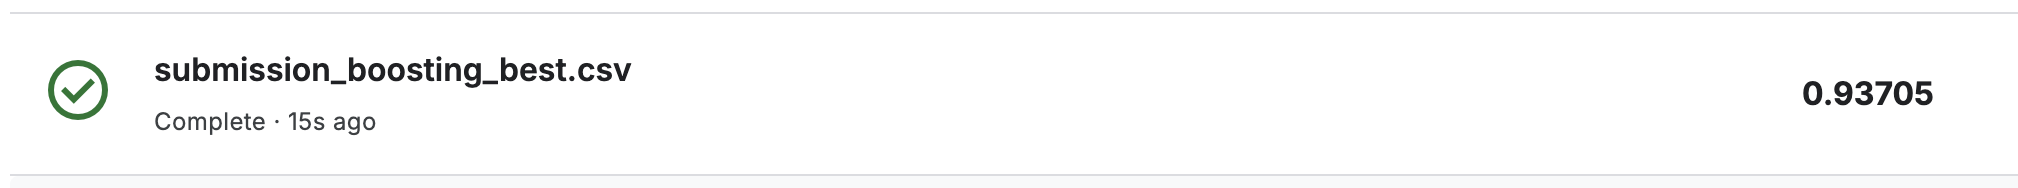

***Для фінального submission було обрано модель XGBoost tuned (Hyperopt), оскільки вона показала найкращу якість на валідаційній вибірці серед усіх протестованих моделей. Після підбору гіперпараметрів за допомогою Hyperopt значення AUROC для XGBoost збільшилось порівняно з базовою моделлю (з 0.9304 до 0.9373). Також ця модель показала трохи кращий результат, ніж LightGBM tuned (0.9368).***

***Враховуючи, що XGBoost є потужним алгоритмом градієнтного бустингу, який добре працює з табличними даними, а також після оптимізації гіперпараметрів демонструє найвищий AUROC, використовуємо саме цю модель у фіналі для submission.***